In [52]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from hydra_pspec import sys_solver as ss
import matplotlib.pyplot as plt
import numpy as np
from uvtools.dspec import gen_window
from uvtools.utils import FFT, fourier_freqs
# pr=cProfile.Profile()
from pyuvdata import UVData
from uvtools.plot import waterfall


In [21]:
def get_uvh5_data(path):
    uvd=UVData()
    uvd.read(path)
    antpairpols = uvd.get_antpairpols()
    vis=uvd.get_data(antpairpols[0], force_copy=True)
    freqs=uvd.freq_array[0]
    lsts=uvd.lst_array
    return vis, freqs, lsts

def data_dly_fr(data, freqs, times, windows=None,
                    freq_window_kwargs=None, time_window_kwargs=None):
    """
    Transform data to delay fringe-rate space
    
    This function takes a 2D array of visibility data (in units of Jy), as well 
    as the corresponding frequency and time arrays (in units of Hz and JD, respectively), 
    and makes a 2x2 grid of plots where each plot shows each one of the possible choices 
    for Fourier transforming along an axis. The upper-left plot is in the frequency-time 
    domain; the upper-right plot is in the frequency-fringe-rate domain; the lower-left 
    plot is in the delay-time domain; and the lower-right plot is in the delay-fringe-rate 
    domain.
    
    Parameters
    ----------
    data : ndarray, shape=(NTIMES,NFREQS)
        Array containing the visibility to be plotted. Assumed to be in units of Jy. 
        
    freqs : ndarray, shape=(NFREQS,)
        Array containing the observed frequencies. Assumed to be in units of Hz.
        
    times : ndarray, shape=(NTIMES,)
        Array containing the observed times. Assumed to be in units of JD.
        
    windows : tuple of str or str, optional
        Choice of taper to use for the fringe-rate and delay transforms. Must be 
        either tuple, list, or string. If a tuple or list, then it must be either 
        length 1 or length 2; if it is length 2, then the zeroth entry is the taper 
        to be applied along the time axis for the fringe-rate transform, with the 
        other entry specifying the taper to be applied along the frequency axis 
        for the delay transform. Each entry is passed to uvtools.dspec.gen_window. 
        If ``windows`` is a length 1 tuple/list or a string, then it is assumed 
        that the same taper is to be used for both axes. Default is to use no 
        taper (or, equivalently, a boxcar).

    freq_window_kwargs : dict, optional
        Keyword arguments to pass to uvtools.dspec.gen_window for generating the 
        frequency taper. Default is to pass no keyword arguments.
        
    time_window_kwargs : dict, optional
        Keyword arguments to pass to uvtools.dspec.gen_window for generating the 
        time taper. Default is to pass no keyword arguments.
    
    Returns
    -------
    data_dl_fr :
        data in delay-fringe rate space
    """
    # do some data prep
    freq_window_kwargs = freq_window_kwargs or {}
    time_window_kwargs = time_window_kwargs or {}
    if windows is not None:
        time_window = gen_window(windows, times.size, **time_window_kwargs)
        freq_window = gen_window(windows, freqs.size, **freq_window_kwargs)
    else:
        time_window = gen_window(None, times.size, **time_window_kwargs)
        freq_window = gen_window(None, freqs.size, **freq_window_kwargs)
        
    time_window = time_window[:, None]
    freq_window = freq_window[None, :]
    # data_fr = FFT(data * time_window, axis=0)
    # data_dly = FFT(data * freq_window, axis=1)
    data_fr_dly = FFT(FFT(data * time_window, axis=0) * freq_window, axis=1)
    
    # fringe_rates = fourier_freqs(times * units.day.to('s')) * 1e3 # mHz
    # dlys = fourier_freqs(freqs) * 1e9 # ns

    return data_fr_dly


Telescope Hex37-14.6m is not in known_telescopes.


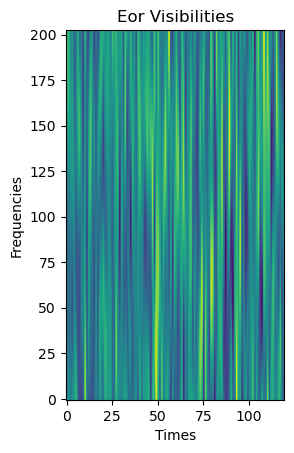

Text(0.5, 1.0, 'EoR visibilities in delay fringe rate space')

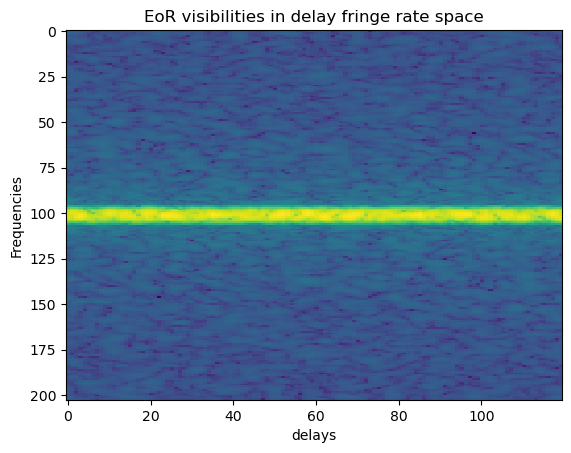

In [47]:
vis, freqs, lsts = get_uvh5_data('repo-test-data/vis-eor.uvh5')
lsts=np.unique(lsts)
vis_dl_fr=data_dly_fr(data=vis,freqs=freqs,times=lsts,windows='blackman-harris')
plt.imshow(vis.real,origin='lower')
plt.title("Eor Visibilities")
plt.xlabel('Times')
plt.ylabel('Frequencies')
plt.show()
waterfall(vis_dl_fr)
plt.xlabel('delays')
plt.ylabel('Frequencies')
plt.title('EoR visibilities in delay fringe rate space')

Telescope Hex37-14.6m is not in known_telescopes.


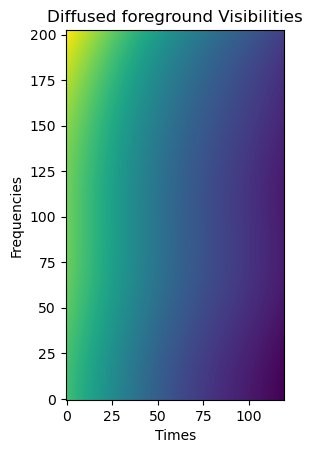

Text(0.5, 1.0, 'Diffused foreground visibilities in delay fringe rate space')

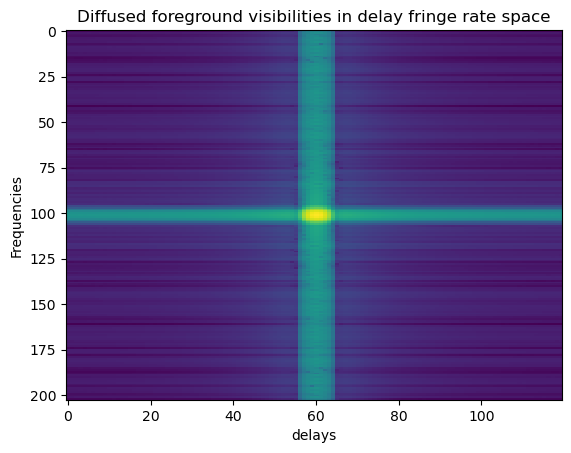

In [44]:
vis, freqs, lsts = get_uvh5_data('repo-test-data/vis-gsm.uvh5')
lsts=np.unique(lsts)
vis_dl_fr=data_dly_fr(data=vis,freqs=freqs,times=lsts,windows='blackman-harris')
plt.imshow(vis.real,origin='lower')
plt.title("Diffused foreground Visibilities")
plt.xlabel('Times')
plt.ylabel('Frequencies')
plt.show()
waterfall(vis_dl_fr)
plt.xlabel('delays')
plt.ylabel('Frequencies')
plt.title('Diffused foreground visibilities in delay fringe rate space')

Telescope Hex37-14.6m is not in known_telescopes.


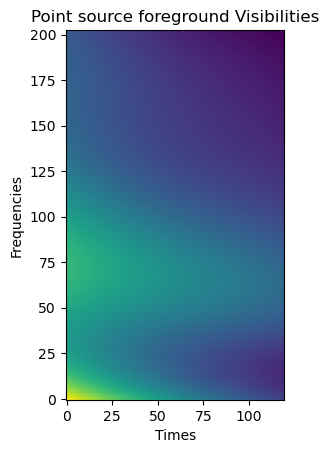

Text(0.5, 1.0, 'Point source foreground visibilities in delay fringe rate space')

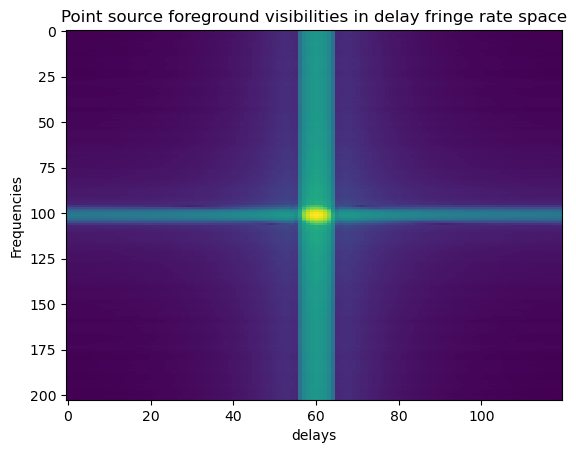

In [45]:
vis, freqs, lsts = get_uvh5_data('repo-test-data/vis-ptsrc.uvh5')
lsts=np.unique(lsts)
vis_dl_fr=data_dly_fr(data=vis,freqs=freqs,times=lsts,windows='blackman-harris')
plt.imshow(vis.real,origin='lower')
plt.title("Point source foreground Visibilities")
plt.xlabel('Times')
plt.ylabel('Frequencies')
plt.show()
waterfall(vis_dl_fr)
plt.xlabel('delays')
plt.ylabel('Frequencies')
plt.title('Point source foreground visibilities in delay fringe rate space')

Telescope Hex37-14.6m is not in known_telescopes.


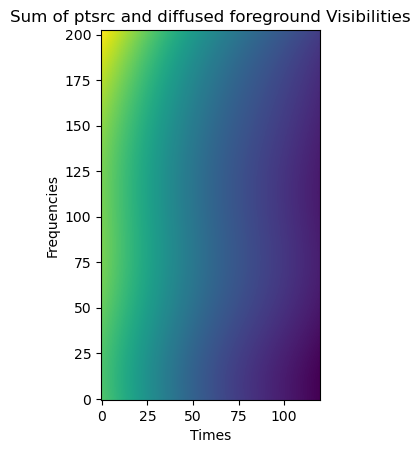

Text(0.5, 1.0, 'Sum of ptsrc and diffused foreground visibilities in delay fringe rate space')

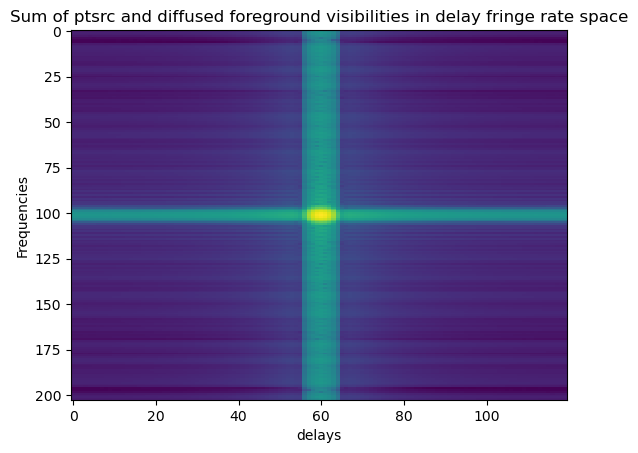

In [46]:
vis, freqs, lsts = get_uvh5_data('repo-test-data/vis-ptsrc-gsm.uvh5')
lsts=np.unique(lsts)
vis_dl_fr=data_dly_fr(data=vis,freqs=freqs,times=lsts,windows='blackman-harris')
plt.imshow(vis.real,origin='lower')
plt.title("Sum of ptsrc and diffused foreground Visibilities")
plt.xlabel('Times')
plt.ylabel('Frequencies')
plt.show()
waterfall(vis_dl_fr)
plt.xlabel('delays')
plt.ylabel('Frequencies')
plt.title('Sum of ptsrc and diffused foreground visibilities in delay fringe rate space')

In [48]:
eor, freqs, lsts=get_uvh5_data('repo-test-data/vis-eor.uvh5')
diff_fg, freqs, lsts=get_uvh5_data('repo-test-data/vis-gsm.uvh5')
ptsrc_fg, freqs, lsts=get_uvh5_data('repo-test-data/vis-ptsrc-gsm.uvh5')
lsts=np.unique(lsts)

Telescope Hex37-14.6m is not in known_telescopes.
Telescope Hex37-14.6m is not in known_telescopes.
Telescope Hex37-14.6m is not in known_telescopes.


In [49]:
summed=eor+diff_fg+ptsrc_fg

In [50]:
vis_dl_fr=data_dly_fr(data=summed,freqs=freqs,times=lsts,windows='blackman-harris')

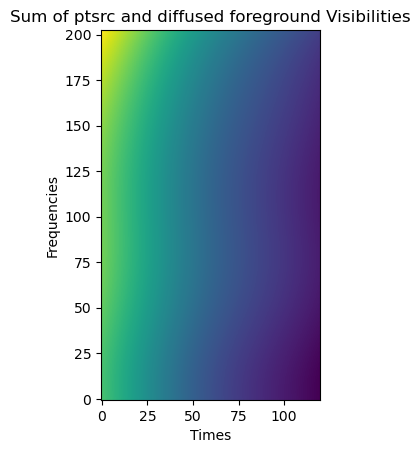

Text(0.5, 1.0, 'Sum of ptsrc and diffused foreground visibilities in delay fringe rate space')

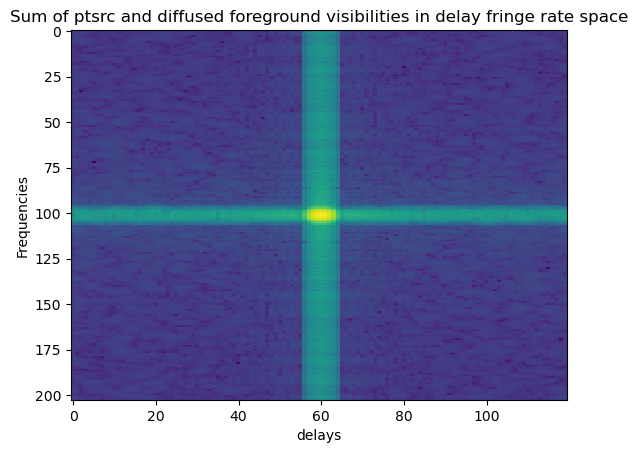

In [51]:
plt.imshow(summed.real,origin='lower')
plt.title("Sum of ptsrc and diffused foreground Visibilities")
plt.xlabel('Times')
plt.ylabel('Frequencies')
plt.show()
waterfall(vis_dl_fr)
plt.xlabel('delays')
plt.ylabel('Frequencies')
plt.title('Sum of ptsrc and diffused foreground visibilities in delay fringe rate space')

# Looking at low correlation data

Telescope Hex37-14.6m is not in known_telescopes.


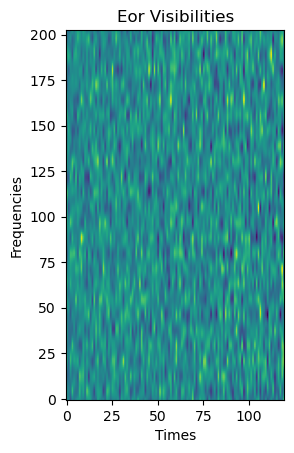

Text(0.5, 1.0, 'EoR visibilities in delay fringe rate space')

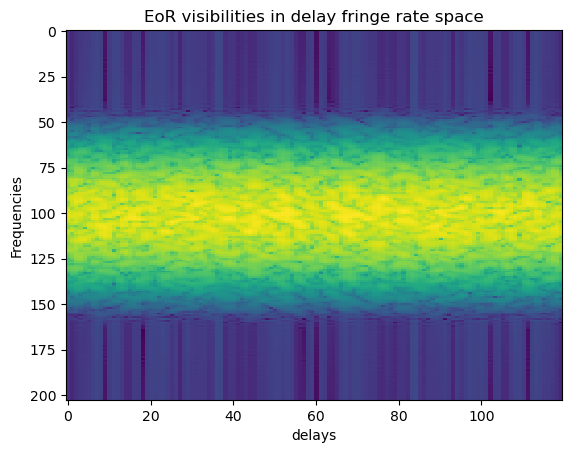

In [56]:
vis, freqs, lsts = get_uvh5_data('/Users/user/Documents/Codes/hydra_sys_project1/hydra-pspec-systematic-multiplicative/test_data/vis-eor.uvh5')
lsts=np.unique(lsts)
vis_dl_fr=data_dly_fr(data=vis,freqs=freqs,times=lsts,windows='blackman-harris')
plt.imshow(vis.real,origin='lower')
plt.title("Eor Visibilities")
plt.xlabel('Times')
plt.ylabel('Frequencies')
plt.show()
waterfall(vis_dl_fr)
plt.xlabel('delays')
plt.ylabel('Frequencies')
plt.title('EoR visibilities in delay fringe rate space')

Telescope Hex37-14.6m is not in known_telescopes.


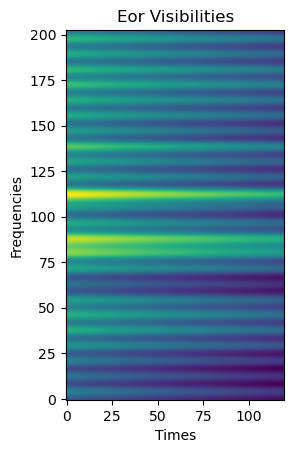

Text(0.5, 1.0, 'EoR+ptscr+gsm visibilities in delay fringe rate space')

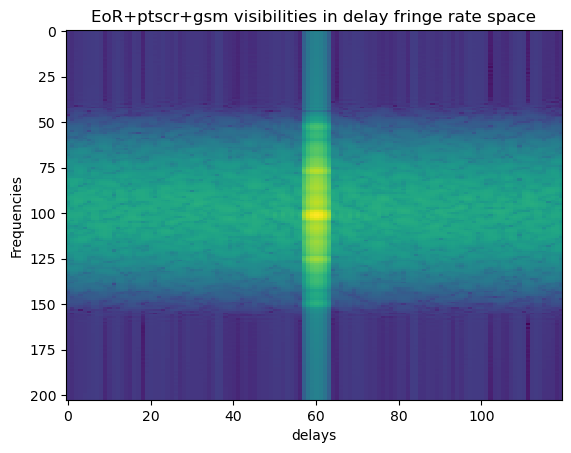

In [94]:
vis, freqs, lsts = get_uvh5_data('/Users/user/Documents/Codes/hydra_sys_project1/hydra-pspec-systematic-multiplicative/test_data/vis-eor-ptsrc-gsm.uvh5')
lsts=np.unique(lsts)
vis_dl_fr=data_dly_fr(data=vis,freqs=freqs,times=lsts,windows='blackman-harris')
plt.imshow(vis.real,origin='lower')
plt.title("Eor Visibilities")
plt.xlabel('Times')
plt.ylabel('Frequencies')
plt.show()
waterfall(vis_dl_fr)
plt.xlabel('delays')
plt.ylabel('Frequencies')
plt.title('EoR+ptscr+gsm visibilities in delay fringe rate space')

Telescope Hex37-14.6m is not in known_telescopes.


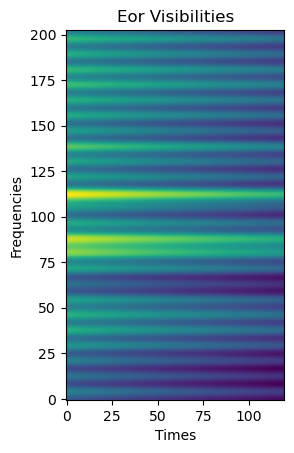

Text(0.5, 1.0, 'ptscr+gsm visibilities in delay fringe rate space')

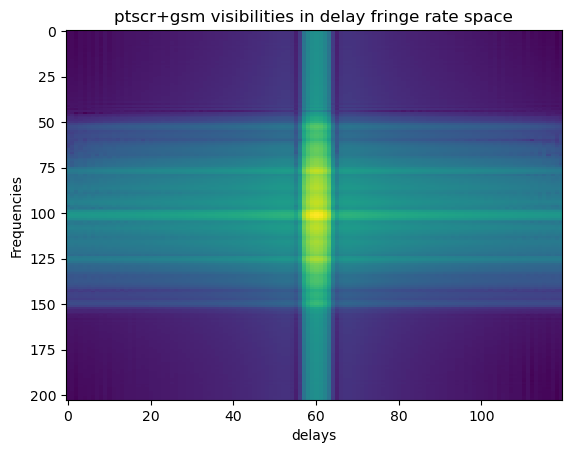

In [60]:
vis, freqs, lsts = get_uvh5_data('/Users/user/Documents/Codes/hydra_sys_project1/hydra-pspec-systematic-multiplicative/test_data/vis-ptsrc-gsm.uvh5')
lsts=np.unique(lsts)
vis_dl_fr=data_dly_fr(data=vis,freqs=freqs,times=lsts,windows='blackman-harris')
plt.imshow(vis.real,origin='lower')
plt.title("Eor Visibilities")
plt.xlabel('Times')
plt.ylabel('Frequencies')
plt.show()
waterfall(vis_dl_fr)
plt.xlabel('delays')
plt.ylabel('Frequencies')
plt.title('ptscr+gsm visibilities in delay fringe rate space')

Telescope Hex37-14.6m is not in known_telescopes.


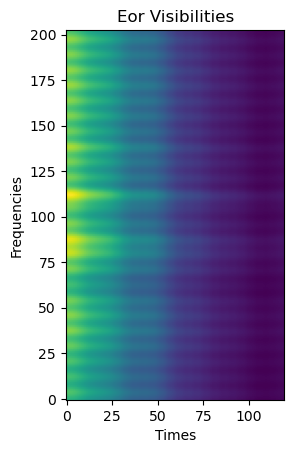

Text(0.5, 1.0, 'ptscr+gsm visibilities in delay fringe rate space')

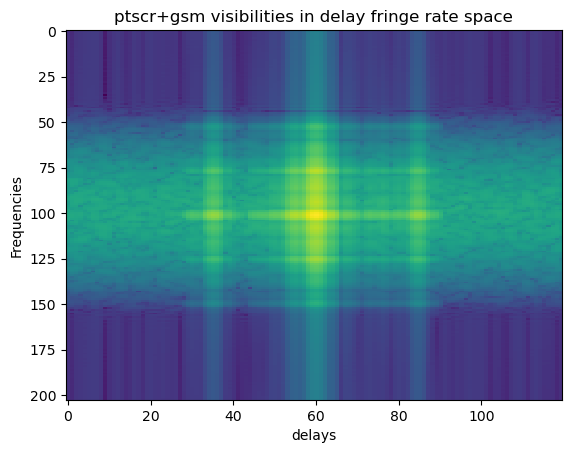

In [61]:
vis, freqs, lsts = get_uvh5_data('/Users/user/Documents/Codes/hydra_sys_project1/hydra-pspec-systematic-multiplicative/test_data/vis_corrupted_gauss_1.uvh5')
lsts=np.unique(lsts)
vis_dl_fr=data_dly_fr(data=vis,freqs=freqs,times=lsts,windows='blackman-harris')
plt.imshow(vis.real,origin='lower')
plt.title("Eor Visibilities")
plt.xlabel('Times')
plt.ylabel('Frequencies')
plt.show()
waterfall(vis_dl_fr)
plt.xlabel('delays')
plt.ylabel('Frequencies')
plt.title('ptscr+gsm visibilities in delay fringe rate space')

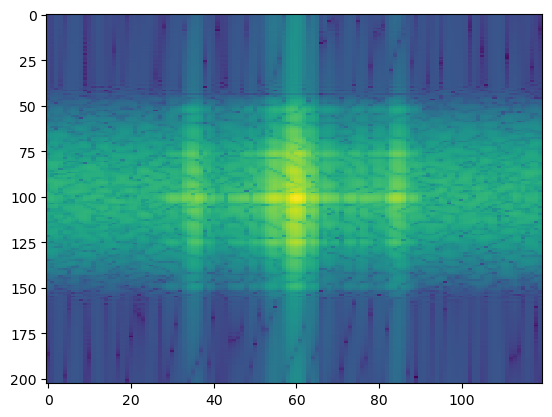

In [63]:
waterfall(vis_dl_fr.real)

# Adding simpler systematics

Telescope Hex37-14.6m is not in known_telescopes.


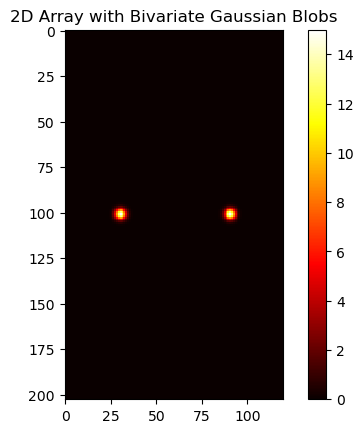

In [130]:
import numpy as np
import matplotlib.pyplot as plt

def create_bivariate_gaussian_blobs(shape, y_center, sigma_x=2, sigma_y=2):
    """
    Create a 2D array with two bivariate Gaussian blobs reflected along the x-axis.

    Parameters:
    - shape: tuple, shape of the output array (height, width)
    - y_center: float, the y-coordinate where the blobs are centered
    - sigma_x: float, standard deviation in the x direction
    - sigma_y: float, standard deviation in the y direction

    Returns:
    - padded_array: 2D numpy array with Gaussian blobs and 1s padding
    """
    height, width = shape
    y = np.linspace(0, height - 1, height)
    x = np.linspace(0, width - 1, width)
    
    # Create meshgrid for the coordinates
    X, Y = np.meshgrid(x, y)

    # Create two Gaussian blobs
    blob1 = 15*np.exp(-((Y - y_center)**2 / (2 * sigma_y**2)) - ((X - (width / 4))**2 / (2 * sigma_x**2)))
    blob2 = 15*np.exp(-((Y - y_center)**2 / (2 * sigma_y**2)) - ((X - (3 * width / 4))**2 / (2 * sigma_x**2)))

    # Combine blobs and ensure they are reflected along the x-axis
    combined_blobs = blob1 + blob2

    # Create the final padded array with 1s
    padded_array = np.zeros(shape)
    padded_array[combined_blobs > 0] = combined_blobs[combined_blobs > 0]

    return padded_array
vis, freqs, lsts = get_uvh5_data('test_data/vis-eor-fgs.uvh5')
lsts=np.unique(lsts)
vis_dl_fr=data_dly_fr(data=vis,freqs=freqs,times=lsts,windows='blackman-harris')
# Parameters
shape = vis_dl_fr.shape
y_center = int(vis_dl_fr.shape[0]/2)  # Center y-coordinate for the Gaussian blobs

# Create the array with Gaussian blobs
result_array = create_bivariate_gaussian_blobs(shape, y_center)

# Visualize the result
plt.imshow(result_array, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title('2D Array with Bivariate Gaussian Blobs')
plt.show()

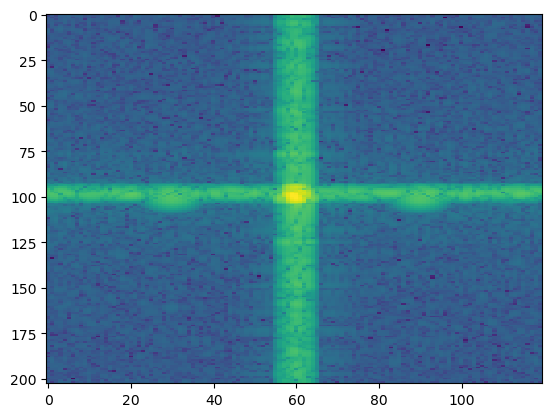

In [133]:
corrupted_array=result_array+vis_dl_fr
waterfall(corrupted_array.real)

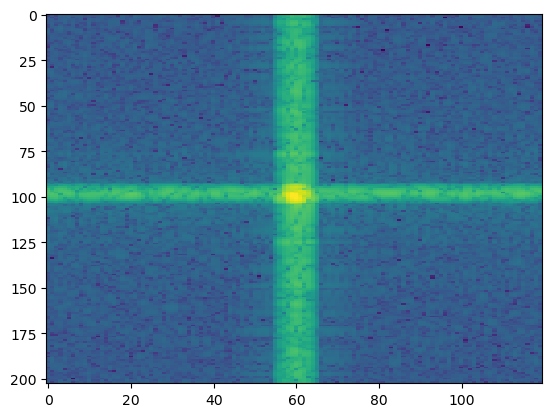

In [134]:
waterfall(vis_dl_fr.real)

In [67]:
eor_cov.shape

(120, 120)

In [69]:
cov_matrix.shape

(120, 120)

In [81]:
import numpy as np

# Use np.array_equal to check if all elements are equal
are_equal = np.array_equal(eor_cov.T, cov_matrix)

if are_equal:
    print("The two arrays are identical.")
else:
    print("The two arrays are not the same.")


The two arrays are not the same.


In [85]:
eigvals, eigvecs = np.linalg.eigh(eor_cov)

In [83]:
cov_matrix

array([[ 0.11639688+7.15227761e-20j,  0.03695565+3.31488290e-02j,
         0.0043081 +8.72393047e-02j, ...,  0.04370746+9.36770634e-02j,
        -0.03200826+4.04049971e-02j,  0.06357672+1.60340307e-02j],
       [ 0.03695565-3.31488290e-02j,  0.27288101-4.77987866e-20j,
        -0.05062388+4.22816240e-02j, ..., -0.01443236-2.20977102e-04j,
        -0.16861355-9.56261044e-02j, -0.0621309 +7.55435007e-02j],
       [ 0.0043081 -8.72393047e-02j, -0.05062388-4.22816240e-02j,
         0.27446073-5.47976428e-19j, ...,  0.16428196+1.57943491e-01j,
         0.2850639 +1.36272949e-01j,  0.06216075-2.03049104e-01j],
       ...,
       [ 0.04370746-9.36770634e-02j, -0.01443236+2.20977102e-04j,
         0.16428196-1.57943491e-01j, ...,  0.33029514+4.42717165e-19j,
         0.19868121-1.12954398e-01j, -0.07778677-1.53491950e-01j],
       [-0.03200826-4.04049971e-02j, -0.16861355+9.56261044e-02j,
         0.2850639 -1.36272949e-01j, ...,  0.19868121+1.12954398e-01j,
         0.49269528+1.14509306e-18j

In [87]:
import numpy as np
vis, freqs, lsts = get_uvh5_data('/Users/user/Documents/Codes/hydra_sys_project1/hydra-pspec-systematic-multiplicative/gauss_1_data/vis-eor.uvh5')
lsts=np.unique(lsts)

def process_eor_visibilities(vis, freqs, baseline=(0, 1)):
    """
    Process EoR visibilities for a specific baseline.
    
    Parameters:
    vis : numpy.ndarray
        The visibility data, assumed to be of shape (n_times, n_freqs, n_baselines).
    freqs : numpy.ndarray
        The frequency array corresponding to the visibility data.
    baseline : tuple
        The baseline to process (default is (0, 1)).
    
    Returns:
    delay_ps_mean : numpy.ndarray
        The time-averaged delay power spectrum.
    prior_bounds : tuple of numpy.ndarray
        The lower and upper prior bounds, 30% below and above the time-averaged delay power spectrum.
    """
    
    # Step 1: Select the visibilities for the specified baseline
    # Assuming vis is a 3D array: (n_times, n_freqs, n_baselines)
    # Extract the visibility for the given baseline
    # If baseline indexing is known, replace 0 with the appropriate index for baseline (0, 1)
    # vis_baseline = vis[:, :, 0]  # Select the 0th baseline for simplicity
    
    # Step 2: Perform FFT along the frequency axis to get the delay spectrum
    # np.fft.fftfreq computes the frequency bins for the FFT, useful for plotting or interpretation
    delay_spectrum = np.fft.fft(vis, axis=1)
    
    # Step 3: Compute the delay power spectrum (absolute value squared)
    delay_power_spectrum = np.abs(delay_spectrum)**2
    
    # Step 4: Average the delay power spectrum over time
    delay_ps_mean = np.mean(delay_power_spectrum, axis=0)
    
    # Step 5: Compute the prior bounds (30% below and above the mean)
    lower_bound = delay_ps_mean * 0.7
    upper_bound = delay_ps_mean * 1.3
    
    # Return the mean delay power spectrum and the prior bounds
    return delay_ps_mean, (lower_bound, upper_bound)


# Example usage:
# Assuming you have visibilities `vis`, frequency array `freqs`, and baseline (0, 1)
# vis.shape = (n_times, n_freqs, n_baselines)
# vis = np.random.randn(100, 64, 1) + 1j * np.random.randn(100, 64, 1)  # Example data
# freqs = np.linspace(100e6, 200e6, 64)  # Example frequency range (100 MHz to 200 MHz)

# Process visibilities for baseline (0, 1)
delay_ps_mean, prior_bounds = process_eor_visibilities(vis, freqs)

print("Time-averaged delay power spectrum:\n", delay_ps_mean)
print("Prior bounds (30% below and above):\n", prior_bounds)

Time-averaged delay power spectrum:
 [0.00156426 0.00112809 0.00184788 0.00133976 0.00150812 0.00143468
 0.00140617 0.00155486 0.00219758 0.00158491 0.00182867 0.0017488
 0.00191051 0.0014272  0.00151833 0.00116518 0.00226544 0.00191397
 0.00190905 0.00181794 0.00230627 0.00119809 0.00120649 0.0011336
 0.0016781  0.0015884  0.00175254 0.00139237 0.00161848 0.00193398
 0.00166104 0.00196016 0.00128773 0.00195995 0.00198657 0.00149053
 0.00132283 0.00167362 0.0016482  0.00151501 0.00170925 0.00144368
 0.00162786 0.00153725 0.00183275 0.0017577  0.00183524 0.00143302
 0.00190225 0.00174043 0.00169467 0.00163103 0.00171111 0.00103454
 0.0016244  0.00140426 0.001297   0.00141065 0.00196931 0.0008851
 0.00206878 0.0008851  0.00196931 0.00141065 0.001297   0.00140426
 0.0016244  0.00103454 0.00171111 0.00163103 0.00169467 0.00174043
 0.00190225 0.00143302 0.00183524 0.0017577  0.00183275 0.00153725
 0.00162786 0.00144368 0.00170925 0.00151501 0.0016482  0.00167362
 0.00132283 0.00149053 0.001

Telescope Hex37-14.6m is not in known_telescopes.


In [92]:
prior_bounds=np.array(prior_bounds)
prior_bounds.shape

(2, 120)